In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

tokenizer = AutoTokenizer.from_pretrained("ncbi/MedCPT-Cross-Encoder")
model = AutoModelForSequenceClassification.from_pretrained("ncbi/MedCPT-Cross-Encoder")
device = 'mps'
model.to(device)

In [2]:
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
from scoring_subtask_2 import compute_evidence_scores, get_leaderboard, load_key

tree = ET.parse("./v1.4/dev/archehr-qa.xml")
root = tree.getroot()

key_map = load_key("./v1.4/dev/archehr-qa_key.json")

In [3]:
data = []
for case in root.findall("case"):
    case_id = case.get('id')
    question = case.findtext("clinician_question", default="").strip()
    sentences = [
        {
            'sentence_id': sentence.get('id'),
            'text': sentence.text.strip()
        }
        for sentence in case.find("note_excerpt_sentences")
    ]
    item = {
        'case_id': case_id,
        'question': question,
        'sentences': sentences
    }
    data.append(item)

In [4]:
from tqdm.notebook import tqdm

dev_scores = []
for case in tqdm(data):
    case_id = case['case_id']
    query = case['question']
    documents = [r['text'] for r in case['sentences']]
    sentence_ids = [r['sentence_id'] for r in case['sentences']]
    pairs = [[query, document] for document in documents]
    with torch.no_grad():
        encoded = tokenizer(
            pairs,
            truncation=True,
            padding=True,
            return_tensors="pt",
            max_length=512,
        ).to(device)
    
        logits = model(**encoded).logits.squeeze(dim=1).cpu().tolist()
    scores_with_ids = [{'id': x, 'score': y} for x, y in zip(sentence_ids, logits)]
    dev_scores.append({'case_id': case_id, 'scores': scores_with_ids})

  0%|          | 0/20 [00:00<?, ?it/s]

In [5]:
import numpy as np

thresholds = np.arange(-15,16)
overalls = []

for threshold in thresholds:
    submission = [{'case_id': c['case_id'], 'prediction': [i['id'] for i in c['scores'] if i['score']>threshold]} for c in dev_scores]
    scores = compute_evidence_scores(submission, key_map)
    leaderboard = get_leaderboard(scores)
    overall = leaderboard['overall_score']
    overalls.append(overall)

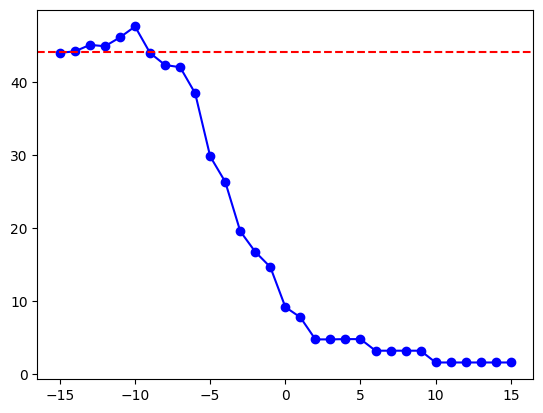

In [6]:
import matplotlib.pyplot as plt

x = thresholds
y = overalls

plt.plot(x, y, marker='o', linestyle='-', color='b')
plt.axhline(44.08, linestyle='--', color='r')
plt.show()

In [7]:
# save thresholds and overalls for plotting later
np.save('./dev_results/medcpt_thresholds', thresholds)
np.save('./dev_results/medcpt_overalls', overalls)

In [8]:
all_scores = [s['score'] for c in dev_scores for s in c['scores']]

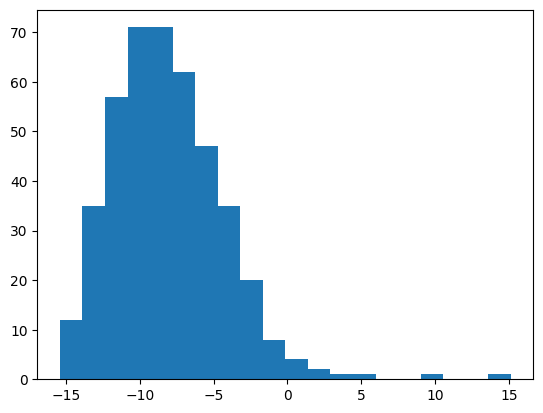

In [9]:
plt.hist(all_scores, bins=20)
plt.show()

In [10]:
dict(zip(thresholds, overalls))

{np.int64(-15): 44.03669724770643,
 np.int64(-14): 44.237918215613384,
 np.int64(-13): 45.124282982791584,
 np.int64(-12): 44.93927125506073,
 np.int64(-11): 46.15384615384615,
 np.int64(-10): 47.64267990074441,
 np.int64(-9): 44.01114206128134,
 np.int64(-8): 42.36760124610592,
 np.int64(-7): 42.06642066420664,
 np.int64(-6): 38.493723849372394,
 np.int64(-5): 29.850746268656714,
 np.int64(-4): 26.373626373626376,
 np.int64(-3): 19.607843137254903,
 np.int64(-2): 16.783216783216783,
 np.int64(-1): 14.705882352941178,
 np.int64(0): 9.230769230769234,
 np.int64(1): 7.8125,
 np.int64(2): 4.8,
 np.int64(3): 4.8,
 np.int64(4): 4.838709677419355,
 np.int64(5): 4.838709677419355,
 np.int64(6): 3.2520325203252036,
 np.int64(7): 3.2520325203252036,
 np.int64(8): 3.2520325203252036,
 np.int64(9): 3.2520325203252036,
 np.int64(10): 1.639344262295082,
 np.int64(11): 1.639344262295082,
 np.int64(12): 1.639344262295082,
 np.int64(13): 1.639344262295082,
 np.int64(14): 1.639344262295082,
 np.int64(1

In [12]:
submission = [{'case_id': c['case_id'], 'prediction': [i['id'] for i in c['scores'] if i['score']>-10]} for c in dev_scores]
scores = compute_evidence_scores(submission, key_map)
leaderboard = get_leaderboard(scores)
leaderboard

{'strict_macro_precision': np.float64(36.00070587601106),
 'strict_macro_recall': np.float64(77.51785714285717),
 'strict_macro_f1': np.float64(47.20110097831318),
 'strict_micro_precision': 34.04255319148936,
 'strict_micro_recall': 79.33884297520662,
 'strict_micro_f1': 47.64267990074441,
 'lenient_macro_precision': np.float64(38.9313147364618),
 'lenient_macro_recall': np.float64(77.51785714285717),
 'lenient_macro_f1': np.float64(49.79983522823847),
 'lenient_micro_precision': 36.50190114068441,
 'lenient_micro_recall': 79.33884297520662,
 'lenient_micro_f1': 50.0,
 'overall_score': 47.64267990074441}